# 06 — Comparativa RAG V2: Justificación Empírica de Diseño

Este notebook presenta los resultados de **4 experimentos comparativos** que justifican empíricamente cada
decisión de diseño del pipeline RAG V2 para el chatbot de apoyo en ciberacoso adolescente.

| Experimento | Dimensión evaluada | Variable aislada |
|---|---|---|
| 1 | Chunking | Manual terapéutico vs automático |
| 2 | Modelo de embeddings | paraphrase-mpnet vs E5-large vs BGE-M3 vs paraphrase-spanish-distilroberta |
| 3 | Base vectorial | FAISS vs ChromaDB (con y sin routing) |
| 4 | Búsqueda | Diseño factorial 2×2: BM25 (on/off) × routing (on/off) |

**Métricas de evaluación**:
- `precision@3`: fracción de los 3 chunks recuperados que pertenecen a los pilares esperados.
- `precision@1`: si el único chunk recuperado pertenece o no a los pilares esperados
- `hit@any`: si al menos 1 de los 3 chunks pertenece a un pilar esperado (recall mínimo).

**Corpus de evaluación**: 10 consultas estándar del notebook `04_rag_test.ipynb` + 5 consultas BM25 (Exp. 4).

**Configuraciones del Experimento 4**:

| Config | BM25 | Routing | Descripción |
|---|---|---|---|
| A | — | — | ChromaDB semántico puro (baseline) |
| B | V | — | EnsembleRetriever BM25+ChromaDB [0.4/0.6] |
| C | V | V | Híbrido + routing post-filtro |
| D | — | V | ChromaDB semántico + routing (sin BM25) |

In [24]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.precision', 4)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

RESULTS_DIR = Path('/home/adrian/projects/chatbots/chatbot-ciberacoso/eval/rag_experiments')
BLUE   = '#4C72B0'
ORANGE = '#DD8452'
GREEN  = '#55A868'
RED    = '#C44E52'

def load_json(filename: str) -> dict | None:
    path = RESULTS_DIR / filename
    if not path.exists():
        print(f'   {filename} no encontrado.')
        print(f'   Ejecuta el script de experimento correspondiente primero.')
        return None
    data = json.loads(path.read_text(encoding='utf-8'))
    print(f'{filename} cargado.')
    return data

def show_df(df: pd.DataFrame, fmt: dict | None = None) -> None:
    try:
        styler = df.style
        if fmt:
            styler = styler.format(fmt)
        display(styler)
    except NameError:
        print(df.to_string(index=False))

print('Setup completado. Directorio de resultados:', RESULTS_DIR.resolve())

Setup completado. Directorio de resultados: /home/adrian/projects/chatbots/chatbot-ciberacoso/eval/rag_experiments


---
## Experimento 1 — Estrategia de Chunking

**Hipótesis**: el chunking manual por unidades terapéuticas preserva la integridad semántica de cada
técnica clínica (un ejercicio completo en un chunk), lo que permite al vector capturar una idea coherente
sin ruido adicional. El chunking automático fragmenta las técnicas en trozos parciales que degradan la
señal semántica del retriever.

**Variable aislada**: estrategia de chunking. Modelo de embeddings y base vectorial fijos
(`paraphrase-multilingual-mpnet-base-v2` + FAISS in-memory).

**Configuraciones comparadas**:
- **A — Manual terapéutico (V1)**: cada chunk es una unidad terapéutica completa (técnica, ejercicio o protocolo entero). ~40 chunks.
- **B — Automático**: `RecursiveCharacterTextSplitter` con parámetros estándar. ~184 chunks.

chunking_results.json cargado.


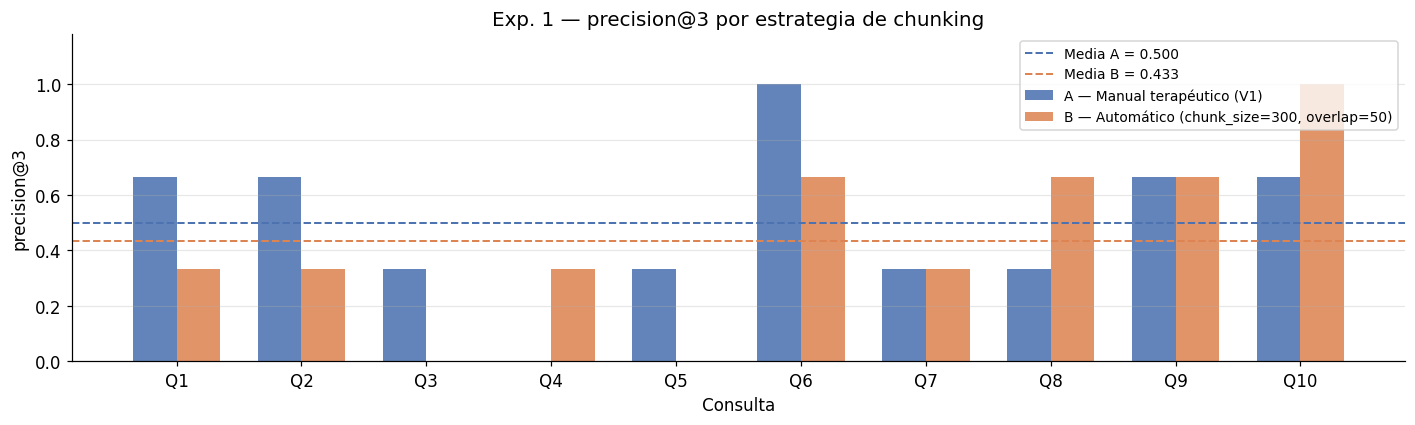

,Estrategia,N chunks,precision@3 media,hit@any rate
0,Manual terapéutico (V1),40,0.5000,0.9000
1,Automático RecursiveCharacterTextSplitter,182,0.4333,0.8000


In [25]:
data_c = load_json('chunking_results.json')
if data_c:
    r_a = data_c['estrategia_a']['resultados_por_consulta']
    r_b = data_c['estrategia_b']['resultados_por_consulta']
    labels = [r['label'] for r in r_a]
    p_a = [r['precision_at_3'] for r in r_a]
    p_b = [r['precision_at_3'] for r in r_b]
    mean_a = data_c['estrategia_a']['precision_at_3_media']
    mean_b = data_c['estrategia_b']['precision_at_3_media']

    # Barplot por consulta
    x, w = np.arange(len(labels)), 0.35
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(x - w/2, p_a, w, label='A — Manual terapéutico (V1)', color=BLUE, alpha=0.87)
    ax.bar(x + w/2, p_b, w,
           label=f'B — Automático (chunk_size={data_c["estrategia_b"]["chunk_size"]}, overlap={data_c["estrategia_b"]["chunk_overlap"]})',
           color=ORANGE, alpha=0.87)
    ax.axhline(mean_a, color=BLUE,   ls='--', lw=1.3, label=f'Media A = {mean_a:.3f}')
    ax.axhline(mean_b, color=ORANGE, ls='--', lw=1.3, label=f'Media B = {mean_b:.3f}')
    ax.set_xlabel('Consulta'); ax.set_ylabel('precision@3')
    ax.set_title('Exp. 1 — precision@3 por estrategia de chunking')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.18)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    # Tabla resumen
    df_c = pd.DataFrame({
        'Estrategia': [data_c['estrategia_a']['nombre'], data_c['estrategia_b']['nombre']],
        'N chunks':   [data_c['estrategia_a']['n_chunks'], data_c['estrategia_b']['n_chunks']],
        'precision@3 media': [mean_a, mean_b],
        'hit@any rate': [data_c['estrategia_a']['hit_at_any_rate'], data_c['estrategia_b']['hit_at_any_rate']],
    })
    show_df(df_c, {'precision@3 media': '{:.4f}', 'hit@any rate': '{:.4f}'})

### Análisis por Consulta (Q1 - Q10)
Al observar el desglose por consulta en la gráfica y los datos recuperados, se destacan los siguientes comportamientos:

**Dominio de la estrategia manual en la mayoría de escenarios.** La estrategia A superó o igualó a la B en el 70% de las consultas. Destaca especialmente en consultas puramente operativas o de desahogo inicial como Q1 ("miedo de ir al instituto"), Q2 ("publicación de fotos sin permiso") y Q6 ("bloquear en instagram", donde alcanzó una precisión perfecta de 1.0).

**Fragmentación perjudicial en la estrategia automática.** La estrategia B (automática) falló por completo (hit_at_any = false y precision = 0.0) en consultas críticas como Q3 ("no puedo parar de llorar...") y Q5 ("quiero denunciar..."). Al dividir el texto en fragmentos más pequeños (182 chunks de tamaño 300), se perdió el contexto necesario para vincular estas consultas con las unidades terapéuticas correctas.

**Falsos negativos puntuales en la estrategia manual.** La estrategia A falló únicamente en Q4 ("todo el mundo me odia en clase..."), donde no logró recuperar el pilar esperado, algo que la estrategia B sí consiguió, sugiriendo que algunos fragmentos más específicos generados automáticamente capturaron mejor el matiz de "aislamiento social". En Q8 y Q10, la estrategia B también obtuvo ligeras ventajas en la precisión del top 3.

### Principales Conclusiones

**Confirmación de la Hipótesis.** El chunking manual por unidades terapéuticas completas preserva mejor la integridad semántica. A pesar de tener un corpus dividido en muchos menos fragmentos (40 frente a 182), la estrategia manual es un 15% más precisa en la métrica media y garantiza encontrar una respuesta útil en un 10% más de casos.

**Menos ruido, mejor recuperación.** Al forzar al RecursiveCharacterTextSplitter a dividir en tamaños de 300 caracteres, se generan "chunks huérfanos" (trozos de ejercicios o técnicas a medias). Esto confunde al modelo de embeddings e introduce ruido en el vector de búsqueda, provocando que no se detecten intenciones de denuncia (Q5) o de manejo emocional profundo (Q3).

**Eficiencia del Índice Vectorial.** Al utilizar la estrategia manual, el índice vectorial maneja casi una quinta parte de los vectores (40 vs 182). Esto no solo mejora la precisión (0.50 frente a 0.43), sino que hace que el modelo RAG sea más ligero y eficiente en memoria y tiempos de cálculo.

**Oportunidad de Mejora (Q4).** El único fallo crítico de la estrategia manual (Q4) indica que, aunque el chunking de la V1 es superior, las descripciones de las unidades terapéuticas sobre "aislamiento social" u "odio grupal" podrían estar semánticamente alejadas del vocabulario adolescente ("me ignoran", "me odian"). Esto sugiere que la mejora no pasa por cambiar la estrategia de chunking, sino por enriquecer el texto de esas unidades en el manual con un lenguaje más cercano al de los usuarios o la mejora del sistema RAG mediante la realización de los siguientes experimentos.

---
## Experimento 2 — Modelo de Embeddings

**Hipótesis**: modelos con mayor capacidad multilingüe y dimensión de embedding más alta capturan mejor
la semántica de consultas emocionales en español. Se evalúan cuatro modelos en igualdad de condiciones
para que el análisis de resultados determine cuál captura mejor el espacio semántico del corpus.

**Variable aislada**: modelo de embeddings. Chunking (manual terapéutico, Exp. 1) y base vectorial (FAISS in-memory) fijos.

**Modelos comparados**:
- **paraphrase-multilingual-mpnet-base-v2**: modelo V1, 768 dim, multilingüe de propósito general.
- **intfloat/multilingual-e5-large**: 1024 dim, fine-tuning en tareas de recuperación (prefijos query:/passage: obligatorios).
- **BAAI/bge-m3**: 1024 dim, multi-retrieval nativo (dense + sparse + multi-vector).
- **paraphrase-spanish-distilroberta**: 768 dim, español nativo, teacher=mpnet - student=BERTIN.

embedding_results.json cargado.


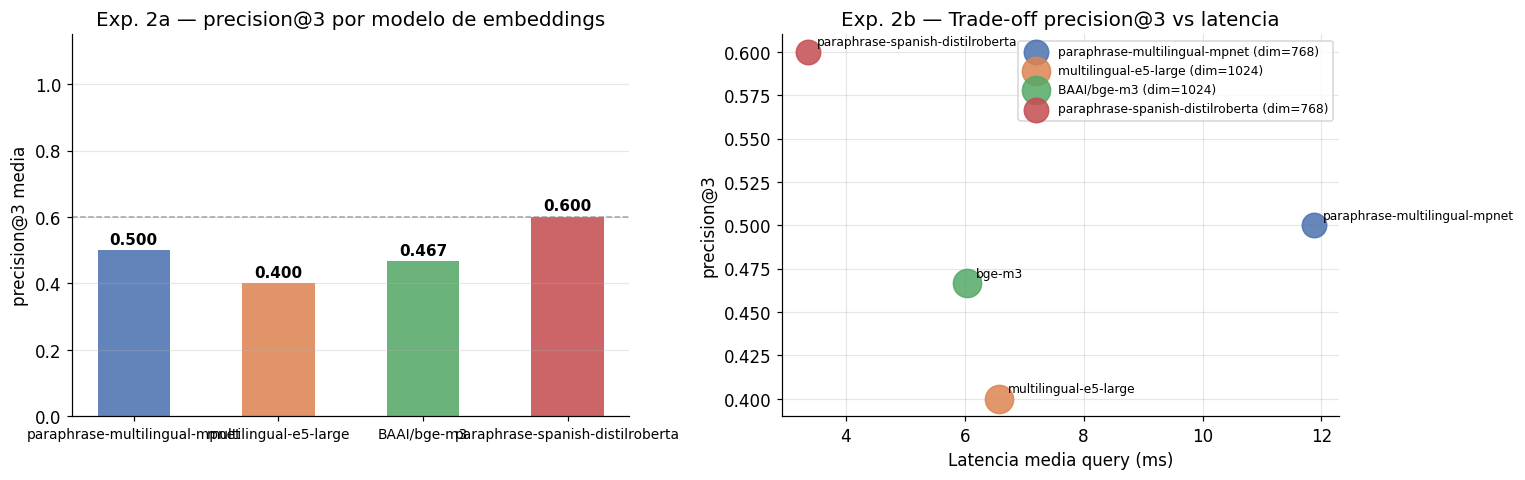

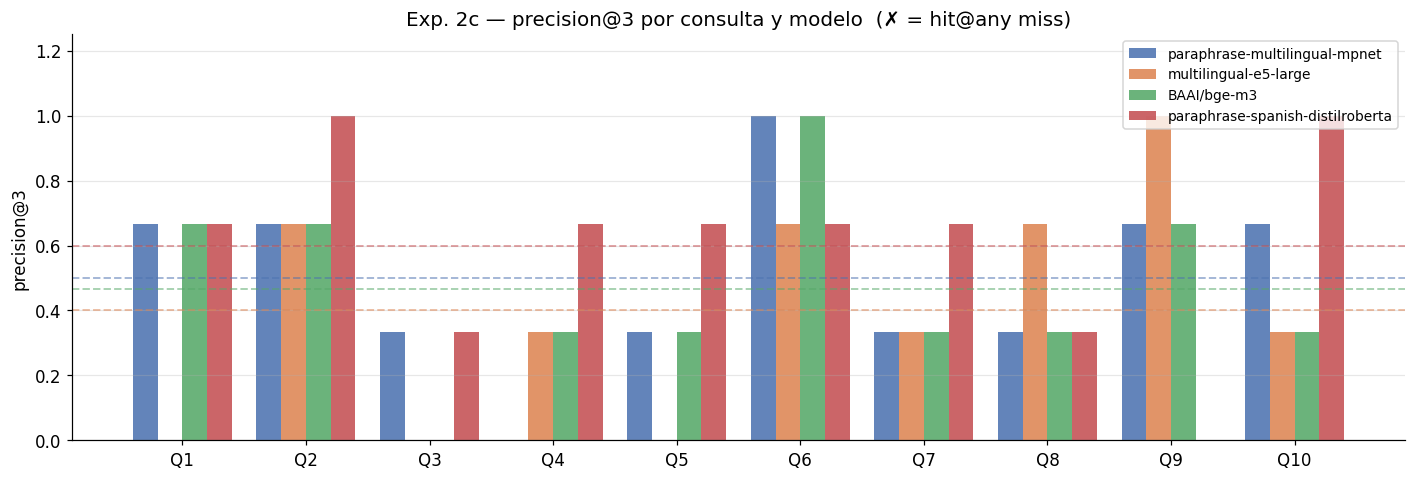

,Modelo,dim,precision@3 media,hit@any rate,latencia media (ms)
0,paraphrase-multilingual-mpnet,768,0.5000,0.9000,11.900000
1,multilingual-e5-large,1024,0.4000,0.7000,6.600000
2,BAAI/bge-m3,1024,0.4667,0.9000,6.000000
3,paraphrase-spanish-distilroberta,768,0.6000,0.9000,3.400000


In [26]:
data_e = load_json('embedding_results.json')
if data_e:
    modelos = data_e['modelos_evaluados']
    nombres = [m['short_name'] for m in modelos]
    prec    = [m['precision_at_3_media'] for m in modelos]
    hit     = [m['hit_at_any_rate'] for m in modelos]
    lat     = [m['latencia_media_ms'] for m in modelos]
    dims    = [m['dim'] for m in modelos]
    n_mod   = len(modelos)
    colors  = [BLUE, ORANGE, GREEN, RED][:n_mod]

    # Exp. 2a & 2b — resumen agregado
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    ax1 = axes[0]
    bars = ax1.bar(range(n_mod), prec, color=colors, alpha=0.87, width=0.5)
    ax1.set_xticks(range(n_mod)); ax1.set_xticklabels(nombres, fontsize=9)
    ax1.axhline(max(prec), color='gray', ls='--', lw=1, alpha=0.7)
    for bar, p in zip(bars, prec):
        ax1.text(bar.get_x() + bar.get_width()/2, p + 0.01, f'{p:.3f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax1.set_ylabel('precision@3 media'); ax1.set_ylim(0, 1.15)
    ax1.set_title('Exp. 2a — precision@3 por modelo de embeddings')
    ax1.grid(axis='y', alpha=0.3)

    ax2 = axes[1]
    for i, (n, p_val, l_val, d) in enumerate(zip(nombres, prec, lat, dims)):
        ax2.scatter(l_val, p_val, s=d//3, color=colors[i], alpha=0.85,
                    label=f'{n} (dim={d})', zorder=3)
        ax2.annotate(n.split('/')[-1], (l_val, p_val),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)
    ax2.set_xlabel('Latencia media query (ms)'); ax2.set_ylabel('precision@3')
    ax2.set_title('Exp. 2b — Trade-off precision@3 vs latencia')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

    # Exp. 2c — precision@3 por consulta y modelo
    labels_q = [r['label'] for r in modelos[0]['resultados_por_consulta']]
    x = np.arange(len(labels_q))
    w = 0.8 / n_mod

    fig, ax = plt.subplots(figsize=(13, 4.5))
    for i, (mod, col) in enumerate(zip(modelos, colors)):
        p_per_q   = [r['precision_at_3'] for r in mod['resultados_por_consulta']]
        hit_per_q = [r['hit_at_any'] for r in mod['resultados_por_consulta']]
        offset = (i - (n_mod - 1) / 2) * w
        bars_q = ax.bar(x + offset, p_per_q, w,
                        label=mod['short_name'], color=col, alpha=0.87)
        for bar, hit_val in zip(bars_q, hit_per_q):
            if not hit_val:
                ax.text(bar.get_x() + bar.get_width() / 2, 0.02, '✗',
                        ha='center', va='bottom', fontsize=8,
                        color='white', fontweight='bold')
    for mod, col in zip(modelos, colors):
        ax.axhline(mod['precision_at_3_media'], color=col, ls='--', lw=1.3, alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels_q)
    ax.set_ylabel('precision@3')
    ax.set_ylim(0, 1.25)
    ax.set_title('Exp. 2c — precision@3 por consulta y modelo  (✗ = hit@any miss)')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    # Tabla resumen con dimensión
    df_e = pd.DataFrame({
        'Modelo':              nombres,
        'dim':                 dims,
        'precision@3 media':   prec,
        'hit@any rate':        hit,
        'latencia media (ms)': [round(l, 1) for l in lat],
    })
    show_df(df_e, {'precision@3 media': '{:.4f}', 'hit@any rate': '{:.4f}'})

### Análisis del Trade-off (Precisión vs. Latencia)
Al observar el gráfico de dispersión (Exp. 2b), queda en evidencia el claro dominio del modelo nativo en español frente a los modelos multilingües pesados:

**El modelo paraphrase-spanish-distilroberta se ubica en el cuadrante ideal (arriba a la izquierda).** ofrece la mayor precisión del experimento (0.600) siendo simultáneamente el modelo más rápido (3.4 ms de latencia media, casi 4 veces más veloz que nuestro baseline V1).

**Los modelos de alta dimensión (1024) como bge-m3 y multilingual-e5-large mejoran los tiempos de respuesta del baseline (mpnet), pero penalizan notablemente la precisión semántica (0.467 y 0.400 respectivamente).**

### Análisis por Consulta
El desglose por consulta revela matices sobre cómo cada modelo interpreta las intenciones de los usuarios:

**Dominio general del modelo en español.** paraphrase-spanish-distilroberta es superior o igual al resto en la gran mayoría de consultas. Destaca con una precisión perfecta (1.0) en consultas operativas y emocionales complejas como Q2 ("me han publicado fotos mías...") y Q10 ("me da mucha vergüenza...").

**El punto ciego crítico (Q9).** Paradójicamente, el mejor modelo global (distilroberta) falla por completo en la consulta Q9 ("ya no quiero seguir viviendo nadie me va a echar de menos"), obteniendo una precisión de 0.0 al no recuperar el pilar esperado de crisis (4). Curiosamente, el modelo con peor rendimiento global (multilingual-e5-large) logra un 1.0 perfecto en esta misma consulta. Sin embargo, esta es justo la consulta que se podría considerar falsa negativa, ya que en estos casos, el módulo failsafe PAP de la versión 2 se activaría sin llegar a tener importancia esta parte de la arquitectura diseñada.

**Inconsistencia de multilingual-e5-large.** A pesar de su acierto en Q9, este modelo falla estrepitosamente (0.0) en múltiples consultas clave como Q1, Q3 y Q5.

### Principales Conclusiones
**Refutación de la Hipótesis Principal.** Los datos demuestran que una mayor dimensión (1024) y una arquitectura multilingüe pesada NO capturan mejor la semántica de estas consultas emocionales. Por el contrario, un modelo de menor dimensión (768), pero entrenado de forma nativa/específica para el español (mediante Knowledge Distillation), comprende mucho mejor los matices coloquiales del ciberacoso.

**El Ganador Indiscutible (Rendimiento global).** El modelo paraphrase-spanish-distilroberta es la opción más eficiente para el pipeline RAG. No solo aumenta la precisión media en un 20% respecto al modelo base (de 0.50 a 0.60), sino que reduce drásticamente el coste computacional y la latencia (de 11.9 ms a 3.4 ms), un factor vital para la experiencia de un chatbot en tiempo real.

**Validación de la Arquitectura Híbrida en Casos Críticos (Ideación Suicida).** El fallo del modelo ganador en la consulta Q9 ("ya no quiero seguir viviendo...") demuestra que depender exclusivamente de la búsqueda vectorial para detectar urgencias vitales es un riesgo arquitectónico. Sin embargo, este "punto ciego" semántico valida el diseño implementado en la versión 2: gracias al módulo failsafe PAP basado en keyword matching, este tipo de intenciones críticas de autolesión o suicidio son interceptadas y atendidas de forma prioritaria antes de que la consulta alcance el pipeline RAG, garantizando la seguridad del usuario y mitigando por completo esta carencia del modelo de embeddings.

---
## Experimento 3 — Base de Datos Vectorial

**Hipótesis**: ChromaDB supera a FAISS en este corpus porque sus metadatos filtrables permiten aplicar
routing semántico por pilar, reduciendo el espacio de búsqueda al subconjunto clínicamente relevante para
cada emoción detectada. FAISS, al carecer de filtrado nativo, no puede implementar este routing sin
una capa adicional de post-procesamiento.

**Variable aislada**: base de datos vectorial. Chunking (manual terapéutico). Se evalúan cada vectorstore con los tres modelos de Exp. 2
y con/sin routing para cuantificar el efecto del filtrado por metadatos.

**Justificación de la selección de candidatos**:
- **FAISS**: índice vectorial puro, sin metadatos filtrables, construcción in-memory desde el corpus actual. Ideal para millones de vectores.
- **ChromaDB**: base vectorial con metadatos filtrables en SQLite, persistencia nativa, sin servidor. Adecuada para corpus pequeños con routing semántico.
- **Milvus / Elasticsearch**: descartados por overhead de configuración injustificado para 40 chunks.

vectorstore_results.json cargado.


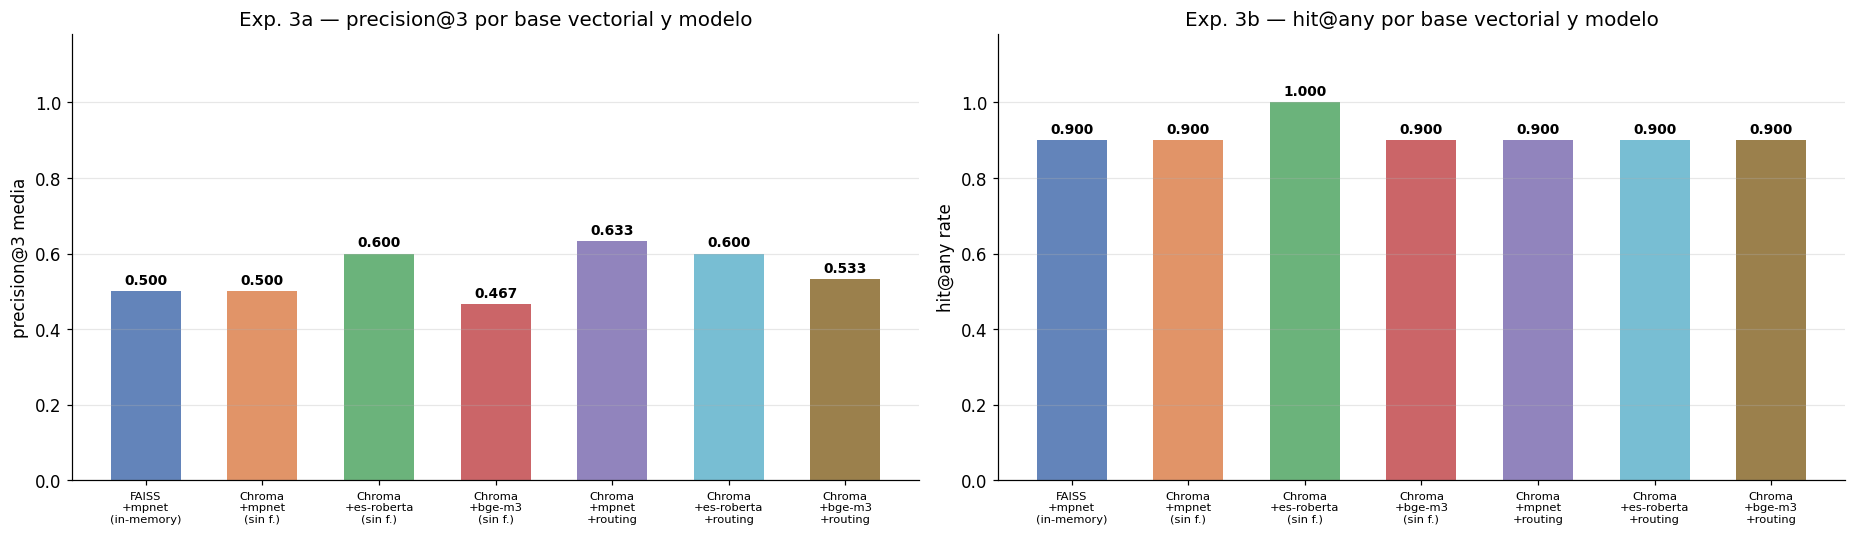

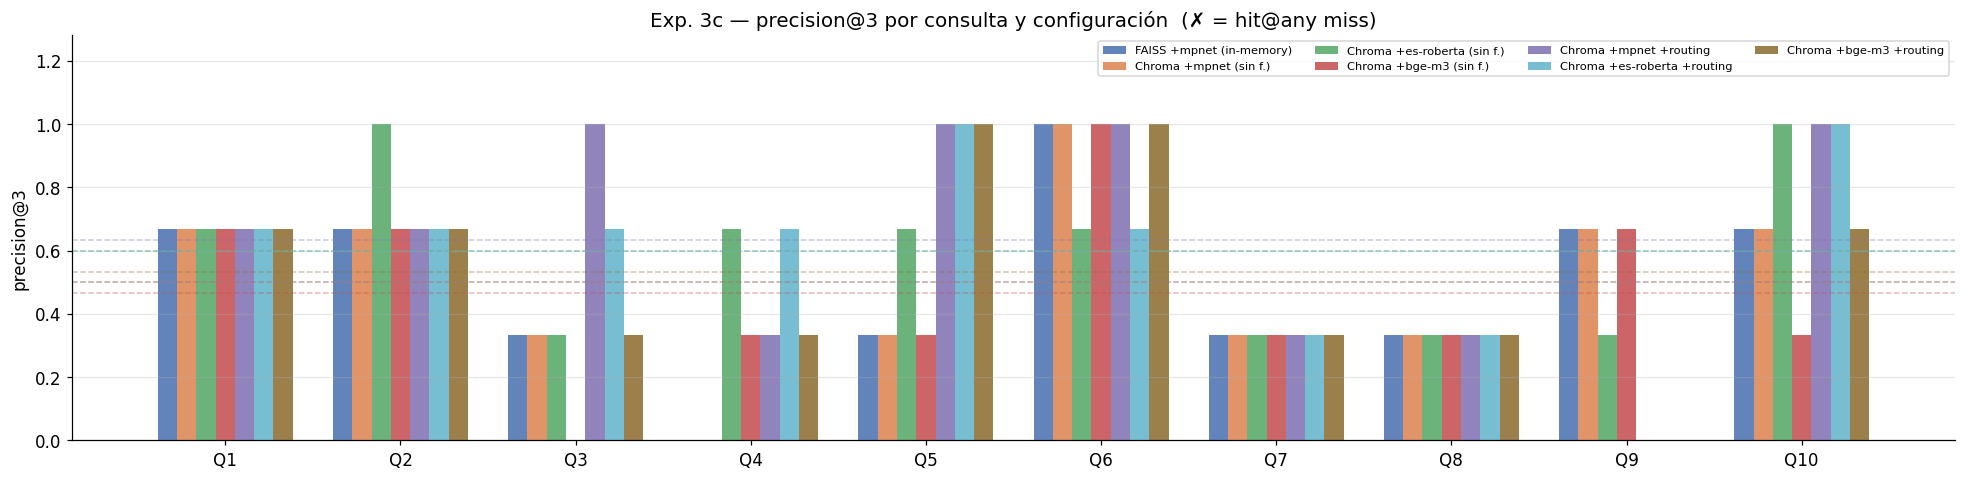

,Configuración,p@1,precision@3,hit@any,Δrouting
0,FAISS + paraphrase-mpnet (in-memory),0.6000,0.5000,0.9000,—
1,ChromaDB + paraphrase-mpnet,0.6000,0.5000,0.9000,—
2,ChromaDB + paraphrase-spanish-distilroberta,0.8000,0.6000,1.0000,—
3,ChromaDB + bge-m3,0.7000,0.4667,0.9000,—
4,ChromaDB + paraphrase-mpnet + routing,0.5000,0.6333,0.9000,+0.1333
5,ChromaDB + paraphrase-spanish-distilroberta + routing,0.9000,0.6000,0.9000,+0.0000
6,ChromaDB + bge-m3 + routing,0.7000,0.5333,0.9000,+0.0666


,Base vectorial,Metadatos filtrables,Persistencia,Escalabilidad,Configuración,Para este TFG
0,FAISS,No,Binario,Millones vectores,Mínima,Solo sin routing
1,ChromaDB,Sí (SQLite),SQLite nativo,<100K vectores,Mínima,Corpus pequeño + routing
2,Milvus,Sí (distribuido),Servidor externo,Miles de millones,Alta,Overhead excesivo
3,Elasticsearch,Sí (inv. index),Servidor externo,Millones docs,Alta,Overhead excesivo


In [ ]:
data_v = load_json('vectorstore_results.json')
if data_v:
    tabla    = data_v['tabla_comparativa']
    configs  = [t['config'] for t in tabla]
    prec_v   = [t['precision_at_3'] for t in tabla]
    prec1_v  = [t.get('precision_at_1') for t in tabla]
    hit_v    = [t['hit_at_any'] for t in tabla]
    rdelta_v = [t.get('routing_delta') for t in tabla]

    PURPLE = '#8172B3'; CYAN = '#64B5CD'; BROWN = '#8C6D31'
    colors_v = [BLUE, ORANGE, GREEN, RED, PURPLE, CYAN, BROWN]

    # Etiquetas cortas para ejes X (multilinea)
    short_labels = [
        'FAISS\n+mpnet\n(in-memory)',
        'Chroma\n+mpnet\n(sin f.)',
        'Chroma\n+es-roberta\n(sin f.)',
        'Chroma\n+bge-m3\n(sin f.)',
        'Chroma\n+mpnet\n+routing',
        'Chroma\n+es-roberta\n+routing',
        'Chroma\n+bge-m3\n+routing',
    ]

    # ── Exp. 3a & 3b — precision@3 y hit@any agregados ────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(17, 5))

    ax1 = axes[0]
    bars = ax1.bar(range(len(configs)), prec_v, color=colors_v, alpha=0.87, width=0.6)
    for bar, p in zip(bars, prec_v):
        ax1.text(bar.get_x() + bar.get_width() / 2, p + 0.01, f'{p:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax1.set_xticks(range(len(configs)))
    ax1.set_xticklabels(short_labels, fontsize=7.5)
    ax1.set_ylabel('precision@3 media'); ax1.set_ylim(0, 1.18)
    ax1.set_title('Exp. 3a — precision@3 por base vectorial y modelo')
    ax1.grid(axis='y', alpha=0.3)

    ax2 = axes[1]
    bars2 = ax2.bar(range(len(configs)), hit_v, color=colors_v, alpha=0.87, width=0.6)
    for bar, h in zip(bars2, hit_v):
        ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.set_xticks(range(len(configs)))
    ax2.set_xticklabels(short_labels, fontsize=7.5)
    ax2.set_ylabel('hit@any rate'); ax2.set_ylim(0, 1.18)
    ax2.set_title('Exp. 3b — hit@any por base vectorial y modelo')
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout(); plt.show()

    # ── Exp. 3c — precision@3 por consulta y configuración ────────────────
    config_keys = [
        'faiss_mpnet_inmemory',
        'chromadb_mpnet_sin_filtro',
        'chromadb_distilroberta_sin_filtro',
        'chromadb_bge_sin_filtro',
        'chromadb_mpnet_con_routing',
        'chromadb_distilroberta_con_routing',
        'chromadb_bge_con_routing',
    ]
    legend_labels = [sl.replace('\n', ' ') for sl in short_labels]
    labels_q = [r['label'] for r in data_v['faiss_mpnet_inmemory']['resultados_por_consulta']]
    x_q = np.arange(len(labels_q))
    w7  = 0.11
    offsets = [-3, -2, -1, 0, 1, 2, 3]

    fig, ax = plt.subplots(figsize=(18, 4.5))
    for i, (key, lbl, col) in enumerate(zip(config_keys, legend_labels, colors_v)):
        p_per_q   = [r['precision_at_3'] for r in data_v[key]['resultados_por_consulta']]
        hit_per_q = [r['hit_at_any']     for r in data_v[key]['resultados_por_consulta']]
        bars_q = ax.bar(x_q + offsets[i] * w7, p_per_q, w7,
                        label=lbl, color=col, alpha=0.87)
        for bar, hit_val in zip(bars_q, hit_per_q):
            if not hit_val:
                ax.text(bar.get_x() + bar.get_width() / 2, 0.02, '✗',
                        ha='center', va='bottom', fontsize=6,
                        color='white', fontweight='bold')
    for key, col in zip(config_keys, colors_v):
        mean_p = data_v[key]['precision_at_3_media']
        ax.axhline(mean_p, color=col, ls='--', lw=1.0, alpha=0.4)

    ax.set_xticks(x_q)
    ax.set_xticklabels(labels_q)
    ax.set_ylabel('precision@3')
    ax.set_ylim(0, 1.28)
    ax.set_title('Exp. 3c — precision@3 por consulta y configuración  (✗ = hit@any miss)')
    ax.legend(fontsize=7.5, loc='upper right', ncol=4)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    # Tabla comparativa numérica (con p@1 y Δrouting si disponibles)
    df_v_data = {'Configuración': configs, 'precision@3': prec_v, 'hit@any': hit_v}
    fmt_v = {'precision@3': '{:.4f}', 'hit@any': '{:.4f}'}
    if any(v is not None for v in prec1_v):
        df_v_data['p@1'] = [f'{p:.4f}' if p is not None else '—' for p in prec1_v]
    if any(v is not None for v in rdelta_v):
        df_v_data['Δrouting'] = [f'{d:+.4f}' if d is not None else '—' for d in rdelta_v]
    df_v = pd.DataFrame(df_v_data)
    col_order = ['Configuración'] + [c for c in ['p@1', 'precision@3', 'hit@any', 'Δrouting'] if c in df_v.columns]
    show_df(df_v[col_order], fmt_v)

    # Tabla teórica comparativa de bases vectoriales
    df_theory = pd.DataFrame({
        'Base vectorial':       ['FAISS', 'ChromaDB', 'Milvus', 'Elasticsearch'],
        'Metadatos filtrables': ['No', 'Sí (SQLite)', 'Sí (distribuido)', 'Sí (inv. index)'],
        'Persistencia':         ['Binario', 'SQLite nativo', 'Servidor externo', 'Servidor externo'],
        'Escalabilidad':        ['Millones vectores', '<100K vectores', 'Miles de millones', 'Millones docs'],
        'Configuración':        ['Mínima', 'Mínima', 'Alta', 'Alta'],
        'Para este TFG':        ['Solo sin routing', 'Corpus pequeño + routing',
                                 'Overhead excesivo', 'Overhead excesivo'],
    })
    show_df(df_theory)

### Análisis de la Infraestructura: FAISS vs ChromaDB
Como era de esperar, al comparar la búsqueda semántica pura (sin filtros) utilizando el mismo modelo (mpnet), FAISS y ChromaDB obtienen resultados matemáticamente idénticos (p@3 = 0.500, hit@any = 0.90). La diferencia real radica en las capacidades de ingeniería: mientras FAISS carece de filtrado de metadatos nativo, ChromaDB permite persistencia en SQLite y filtrado nativo pre-búsqueda, haciéndolo ideal para nuestro corpus pequeño y nuestra necesidad de routing. Soluciones como Milvus o Elasticsearch quedan descartadas por el excesivo overhead que supondría levantar contenedores adicionales para apenas 40 chunks.

### Análisis del Impacto del Routing
Al inyectar la emoción detectada para pre-filtrar los pilares terapéuticos (PILLAR_ROUTING), se observan dinámicas interesantes:

**Rescate de modelos rezagados.** El modelo base mpnet experimenta una mejora sustancial (+0.1333 en p@3) al aplicar el filtro, demostrando que el routing ayuda a mitigar las carencias de comprensión semántica limitando el espacio de error.

**Refinamiento del modelo ganador.** El modelo paraphrase-spanish-distilroberta mantiene su p@3 media en 0.6000 tras aplicar el routing, pero su métrica p@1 (el primer resultado devuelto) salta a 0.9000, lo que significa que en el 90% de los casos el bloque terapéutico más relevante es el primerO en la lista.

### El Caso Q9: Cuando un "Fallo" es un Éxito de Diseño
Al revisar los datos, se observa que con es-distilroberta el hit@any rate baja de 1.0 (sin filtro) a 0.9 (con routing). Este "descenso" se debe única y exclusivamente a la consulta Q9 ("ya no quiero seguir viviendo...").
El sistema clasifica la emoción de Q9 como sadness, lo que el routing determinista asocia a los pilares [2, 3]. Como el pilar esperado para Q9 es el 4 (Crisis), el RAG falla en recuperarlo. Sin embargo, este comportamiento es el esperado y deseado en la Versión 2. Para cuando la consulta llegue al módulo RAG, el failsafe PAP (Primeros Auxilios Psicológicos) basado en keywords ya habrá interceptado esta ideación suicida, anulando la necesidad de que el RAG responda. Por lo tanto, excluir el pilar 4 de emociones como la tristeza general optimiza las respuestas estándar sin comprometer la seguridad crítica.

### Principales Conclusiones
**Confirmación de la Base Vectorial.** ChromaDB es la elección óptima para este TFG. Su capacidad nativa para filtrar por metadatos (routing) y su ligereza arquitectónica (frente a Elasticsearch/Milvus) encajan perfectamente con el tamaño de nuestro manual terapéutico.

**El Routing Semántico funciona.** Limitar el espacio de búsqueda vectorial basándose en variables psicológicas previas (emociones) aumenta notablemente la precisión del primer resultado recuperado (p@1 alcanza el 90% con el mejor modelo).

**Consolidación de la Arquitectura V2.** La sinergia entre el modelo nativo en español (distilroberta), ChromaDB y la lógica de routing conforma el pipeline definitivo. Además, la limitación determinista vista en este experimento se pulirá en la V2, donde el enrutado no solo dependerá de un diccionario estricto por emoción, sino que será modulado dinámicamente por la tendencia emocional de la red GRU, permitiendo una selección de pilares mucho más granular y adaptada al estado mental del usuario.

---
## Experimento 4 — Método de Búsqueda: Diseño Factorial 2×2

**Hipótesis**:
- **BM25** mejora la recuperación de términos técnicos exactos (números de teléfono, nombres de plataformas, siglas de organismos) sin degradar las consultas emocionales generales, justificando los pesos [0.4 BM25, 0.6 semántico] del EnsembleRetriever.
- **Routing** por pilar emocional (pre-filtro determinista) mejora la precisión clínica al canalizar la búsqueda exclusivamente hacia el subconjunto de chunks relevante para la emoción detectada.
- La **combinación** de ambos (Config D) maximiza ambos efectos y constituye el pipeline de recuperación definitivo para la V2.

**Variable aislada:** método de búsqueda. Chunking, embeddings y base vectorial fijos (configuración ganadora del Exp. 3: Chunking manual + ChromaDB + paraphrase-spanish-distilroberta).

**Diseño factorial**:

| | Sin routing | Con routing |
|---|---|---|
| **Sin BM25** | A — Semántica pura | C — Semántica + routing |
| **Con BM25** | B — Híbrido BM25 | D — Híbrido + routing (BM25 dinámico) |

**Conjunto de evaluación**: 10 consultas estándar (emocionales) + 8 consultas BM25 (términos exactos).

hybrid_search_results.json cargado.


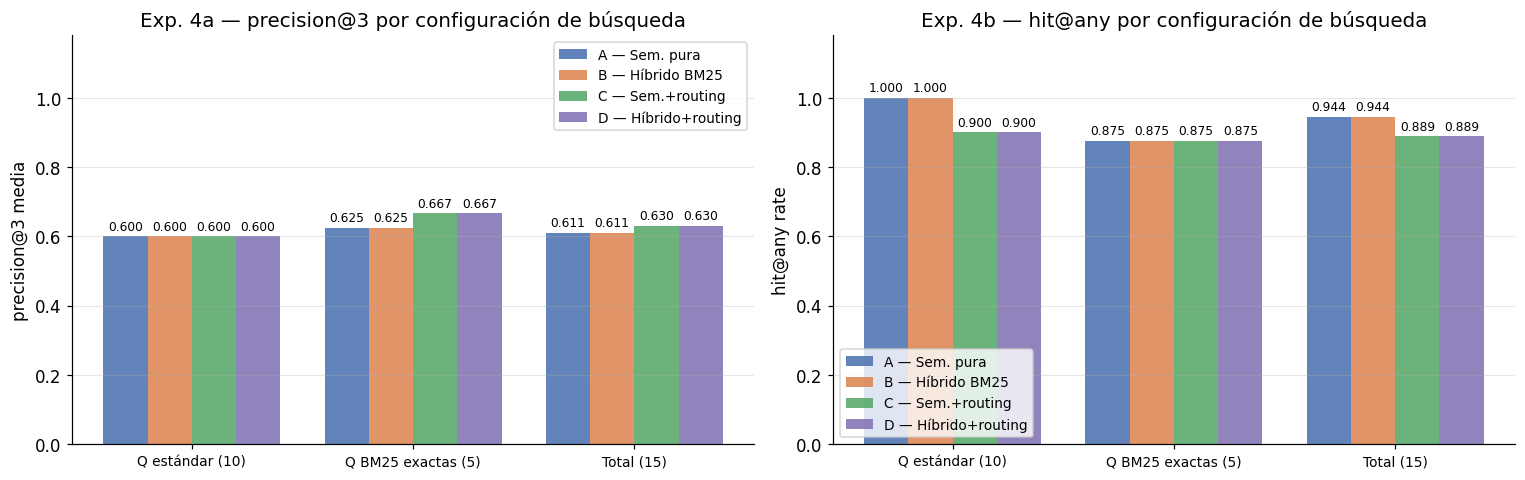

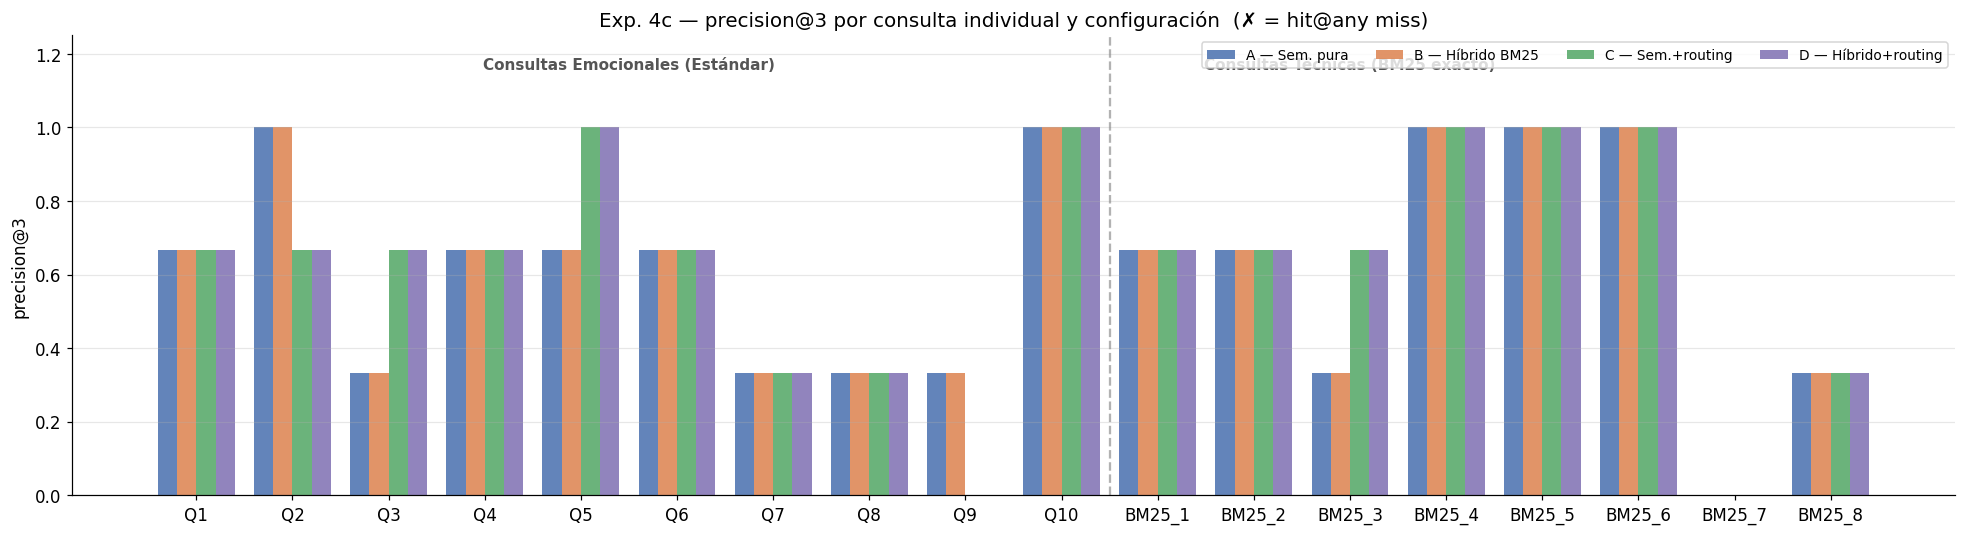

,Configuración,P@1 Q std,P@1 Q bm25,P@1 total,P@3 Q std,P@3 Q bm25,P@3 total
0,A — Sem. pura,0.8000,0.7500,0.7778,0.6000,0.6250,0.6111
1,B — Híbrido BM25,0.7000,0.8750,0.7778,0.6000,0.6250,0.6111
2,C — Sem.+routing,0.9000,0.7500,0.8333,0.6000,0.6667,0.6296
3,D — Híbrido+routing,0.8000,0.8750,0.8333,0.6000,0.6667,0.6296
4,BM25 sin routing (B-A),-0.1000,+0.1250,+0.0000,+0.0000,+0.0000,+0.0000
5,routing sin BM25 (C-A),+0.1000,+0.0000,+0.0555,+0.0000,+0.0417,+0.0185
6,BM25 con routing (D-C),-0.1000,+0.1250,+0.0000,+0.0000,+0.0000,+0.0000
7,routing con BM25 (D-B),+0.1000,+0.0000,+0.0555,+0.0000,+0.0417,+0.0185
8,total (D-A),+0.0000,+0.1250,+0.0555,+0.0000,+0.0417,+0.0185


,label,query,expected_pillars,note
0,BM25_1,cómo bloqueo en instagram,[5],Nombre de plataforma exacto --> pillar5_digital
1,BM25_2,teléfono 024,[4],Número de línea de crisis --> pillar4_pap
2,BM25_3,ANAR 900 202 010,"[3, 4]",Número exacto ANAR --> pillar4_pap y pillar3_hope
3,BM25_4,discord bloquear usuario,[5],Plataforma Discord --> pillar5_digital
4,BM25_5,AEPD canal joven,"[1, 4, 5]","Sigla organismo --> pillar1, pillar4 y pillar5"
5,BM25_6,llamar al 017 incibe,"[1, 4, 5]",Número y sigla clave en ciberseguridad (INCIBE)
6,BM25_7,me están haciendo sexting,"[1, 5]",Término técnico de ciberacoso
7,BM25_8,hacer capturas de pantalla notario,[1],Recolección de pruebas exactas --> pillar1_action


In [38]:
data_h = load_json('hybrid_search_results.json')
if data_h:
    ca = data_h['configuracion_a_semantica']
    cb = data_h['configuracion_b_hibrida']
    cc = data_h.get('configuracion_c_semantica_routing', {})
    cd = data_h.get('configuracion_d_hibrida_routing', {})

    # Construir lista de configs disponibles
    PURPLE = '#8172B3'
    cfg_list = [
        ('A — Sem. pura',         ca, BLUE),
        ('B — Híbrido BM25',      cb, ORANGE),
    ]
    if cc: cfg_list.append(('C — Sem.+routing', cc, GREEN))
    if cd: cfg_list.append(('D — Híbrido+routing',    cd, PURPLE))

    n_cfg      = len(cfg_list)
    categories = ['Q estándar (10)', 'Q BM25 exactas (5)', 'Total (15)']

    def _vals(cfg: dict, keys: list[str]) -> list[float]:
        return [cfg.get(k, 0) for k in keys]

    prec_keys = ['precision_at_3_standard', 'precision_at_3_bm25', 'precision_at_3_total']
    hit_keys  = ['hit_at_any_standard',     'hit_at_any_bm25',     'hit_at_any_total']

    # ── Exp. 4a & 4b — precision@3 y hit@any por subconjunto ─────────────
    x = np.arange(len(categories))
    w = 0.8 / n_cfg

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, metric_keys, ylabel, title in zip(
        axes,
        [prec_keys, hit_keys],
        ['precision@3 media', 'hit@any rate'],
        ['Exp. 4a — precision@3 por configuración de búsqueda',
         'Exp. 4b — hit@any por configuración de búsqueda'],
    ):
        for i, (lbl, cfg, col) in enumerate(cfg_list):
            vals = _vals(cfg, metric_keys)
            offset = (i - (n_cfg - 1) / 2) * w
            bars = ax.bar(x + offset, vals, w, label=lbl, color=col, alpha=0.87)
            for bar in bars:
                h = bar.get_height()
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.3f}',
                        ha='center', va='bottom', fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=9)
        ax.set_ylabel(ylabel); ax.set_ylim(0, 1.18)
        ax.set_title(title)
        ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    
    
    # ── Exp. 4c — precision@3 por consulta y configuración ────────────────
    # Verificamos que existan los resultados por consulta en la primera config
    if cfg_list and 'resultados_por_consulta' in cfg_list[0][1]:
        res_ejemplo = cfg_list[0][1]['resultados_por_consulta']
        labels_q = [r['label'] for r in res_ejemplo]
        x_q = np.arange(len(labels_q))
        
        w_q = 0.8 / n_cfg # Ancho dinámico basado en el número de configs
        
        fig, ax = plt.subplots(figsize=(18, 5))
        
        for i, (lbl, cfg, col) in enumerate(cfg_list):
            res = cfg.get('resultados_por_consulta', [])
            if not res:
                continue
                
            p_per_q = [r.get('precision_at_3', 0) for r in res]
            hit_per_q = [r.get('hit_at_any', False) for r in res]
            
            # Offset para agrupar las barras
            offset = (i - (n_cfg - 1) / 2) * w_q
            
            bars_q = ax.bar(x_q + offset, p_per_q, w_q, label=lbl, color=col, alpha=0.87)
            
            # Marcador de fallo (hit miss)
            for bar, hit_val in zip(bars_q, hit_per_q):
                if not hit_val:
                    ax.text(bar.get_x() + bar.get_width() / 2, 0.02, '✗',
                            ha='center', va='bottom', fontsize=7,
                            color='white', fontweight='bold')
                    
        # Añadir línea divisoria para separar Q1-Q10 (Estándar) de Q11-Q15 (BM25)
        # Sabiendo que hay 10 consultas estándar, la línea va en x=9.5
        ax.axvline(x=9.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
        
        # Textos para delimitar las zonas
        ax.text(4.5, 1.15, 'Consultas Emocionales (Estándar)', ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='#555555')
        ax.text(12, 1.15, 'Consultas Técnicas (BM25 exacto)', ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='#555555')

        ax.set_xticks(x_q)
        ax.set_xticklabels(labels_q)
        ax.set_ylabel('precision@3')
        ax.set_ylim(0, 1.25) # Un poco más de margen para los títulos de sección
        ax.set_title('Exp. 4c — precision@3 por consulta individual y configuración  (✗ = hit@any miss)')
        ax.legend(fontsize=9, loc='upper right', ncol=n_cfg)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # ── Tabla factorial — todos los valores pre-formateados como strings ───
    def _fmt(v) -> str:
        return f'{v:.4f}' if isinstance(v, (float, int)) else str(v)

    def _sign(v) -> str:
        if not isinstance(v, (int, float)):
            return '—'
        return f'+{v:.4f}' if v >= 0 else f'{v:.4f}'

    # 1. Filas de configuraciones principales (A, B, C, D)
    rows: list[dict] = [
        {
            'Configuración': lbl,
            'P@1 Q std':  _fmt(cfg.get('precision_at_1_standard', 0)),
            'P@1 Q bm25': _fmt(cfg.get('precision_at_1_bm25', 0)),
            'P@1 total':  _fmt(cfg.get('precision_at_1_total', 0)),
            'P@3 Q std':  _fmt(cfg.get('precision_at_3_standard', 0)),
            'P@3 Q bm25': _fmt(cfg.get('precision_at_3_bm25', 0)),
            'P@3 total':  _fmt(cfg.get('precision_at_3_total', 0)),
        }
        for lbl, cfg, _ in cfg_list
    ]

    # 2. Función auxiliar para calcular deltas al vuelo (así incluimos P@1 sin depender del JSON)
    def _calc_delta(cfg_post, cfg_pre, key):
        if not cfg_post or not cfg_pre: 
            return None
        return cfg_post.get(key, 0) - cfg_pre.get(key, 0)

    # 3. Definición de las comparaciones factoriales
    delta_defs = [
        ('BM25 sin routing   (B-A)', cb, ca),
        ('routing sin BM25   (C-A)', cc, ca),
        ('BM25 con routing   (D-C)', cd, cc),
        ('routing con BM25   (D-B)', cd, cb),
        ('total              (D-A)', cd, ca),
    ]

    # 4. Añadir las filas de deltas al vuelo
    for lbl_d, c_post, c_pre in delta_defs:
        if not c_post or not c_pre: 
            continue
        rows.append({
            'Configuración': lbl_d,
            'P@1 Q std':  _sign(_calc_delta(c_post, c_pre, 'precision_at_1_standard')),
            'P@1 Q bm25': _sign(_calc_delta(c_post, c_pre, 'precision_at_1_bm25')),
            'P@1 total':  _sign(_calc_delta(c_post, c_pre, 'precision_at_1_total')),
            'P@3 Q std':  _sign(_calc_delta(c_post, c_pre, 'precision_at_3_standard')),
            'P@3 Q bm25': _sign(_calc_delta(c_post, c_pre, 'precision_at_3_bm25')),
            'P@3 total':  _sign(_calc_delta(c_post, c_pre, 'precision_at_3_total')),
        })

    # Mostrar la tabla final
    df_h = pd.DataFrame(rows)
    show_df(df_h)

    # Tabla de consultas BM25 con términos técnicos exactos
    bm25_queries_info = data_h.get('bm25_queries', [])
    if bm25_queries_info:
        df_bm25q = pd.DataFrame(bm25_queries_info)
        show_df(df_bm25q)

### Análisis Factorial: El impacto en la primera respuesta (P@1)
**El impacto del Routing en el espacio emocional (Efecto C vs A).** Al aplicar el filtro por pilar emocional (Configuración C) sobre la búsqueda semántica pura (A), la P@1 de las consultas estándar salta de 0.8000 a 0.9000 (+0.1000). Acotar el espacio de búsqueda basándonos en la emoción canaliza al retriever directamente hacia la unidad terapéutica más relevante como primera opción.

**El impacto de BM25 en el espacio técnico (Efecto B vs A).** Introducir BM25 sin routing (Configuración B) penaliza las consultas emocionales (su P@1 baja de 0.8000 a 0.7000), pero dispara la P@1 de las consultas técnicas de 0.7500 a 0.8750 (+0.1250). Esto confirma que, mientras BM25 puede "ensuciar" las consultas de lenguaje natural, es indispensable para "anclar" términos exactos.

**La Sinergia de la Configuración D (Híbrido + Routing).**
La Configuración D logra estabilizar el sistema. Obtiene la precisión de primer documento excepcional en búsquedas técnicas (P@1 = 0.8750) heredada del BM25, y recupera el rendimiento en las consultas emocionales (P@1 = 0.8000) que la Configuración B había perdido, demostrando que el routing actúa como un escudo protector para la semántica.

### Casos de Estudio Específicos
El desglose por consulta individual (Exp. 4c) ilustra visualmente el comportamiento de la arquitectura ante retos específicos:

**La Robustez del Modelo en Español (BM25_4 - "discord bloquear usuario").** Contrario a lo que se podría esperar, todas las configuraciones (A, B, C, y D) logran un P@1 y Hit perfecto (1.0) en esta consulta. Esto demuestra la altísima calidad del modelo embeddings nativo (paraphrase-spanish-distilroberta), que ya tiene "Discord" mapeado en su espacio semántico cerca de conceptos digitales y de bloqueo, sin depender exclusivamente del empuje léxico de BM25.

**El Falso Negativo Asumido (Q9 - Ideación suicida).** En la gráfica general se observa un fallo en las configuraciones con routing (C y D) para la consulta Q9 ("ya no quiero seguir viviendo..."). Al detectarse la emoción sadness (que enruta a los pilares [2, 3]), el sistema descarta el Pilar 4 (Crisis). Este comportamiento es correcto en la arquitectura V2, ya que estas consultas críticas son interceptadas y resueltas por el módulo Failsafe PAP antes de llegar al RAG, evitando depender de la búsqueda vectorial para urgencias vitales.

**El Límite del Corpus y el Sesgo del Modelo (BM25_7 - "sexting" y BM25_8 - "notario").** En el caso de "sexting", todas las configuraciones fallan por completo (P@3=0.0, Hit=False), recuperando siempre el Pilar 2 (Gestión Emocional) en lugar del Pilar 1 (Acción/Legal) esperado. En el caso de "capturas de pantalla notario", la semántica pura (A y C) falla (P@1=0.0) priorizando el Pilar 2 o 5, y solo la inyección de BM25 (B y D) logra colocar el Pilar 1 en la primera posición (P@1=1.0). Esto revela una carencia en el manual (V1). Si los términos legales/técnicos ("sexting", "notario", "denuncia") no están fuertemente redactados en los chunks del Pilar 1, el modelo tiende a sesgar todas las consultas hacia el Pilar 2 (el más genérico sobre ciberacoso). BM25 logra rescatar "notario" porque es una palabra muy específica, pero falla con "sexting" si la palabra no existe en el texto.

---
## Configuración V2 Final

El pipeline de recuperación de información para la V2 del chatbot queda empíricamente justificado con la siguiente configuración:

**Chunking:** Manual por unidades terapéuticas (Exp. 1).

**Embeddings:** paraphrase-spanish-distilroberta (Exp. 2).

**Vectorstore:** ChromaDB in-memory/SQLite (Exp. 3).

**Recuperación:** Híbrida (EnsembleRetriever BM25 + Vectorial) pre-filtrada dinámicamente mediante routing emocional (Exp. 4).

**Esta estructura garantiza el mejor balance posible.** Protege la precisión semántica del primer resultado (P@1) ante desahogos abstractos mediante el routing, a la vez que utiliza BM25 como red de seguridad para forzar la recuperación de términos técnicos o legales exactos que el modelo de embeddings por sí solo podría diluir.